In [16]:
from pathlib import Path
import sys

src_path = Path.cwd().parent / "src"
sys.path.insert(0, str(src_path))

from main import *
from scipy.linalg import expm

In [39]:
def dissipator_from_builder(builder, jump_operator):
    """
    Construct the Liouville-space matrix D[L] using the user's
    existing LiouvillianBuilder and Jump classes.
    """
    zero_H = np.zeros(
        (builder.d, builder.d),
        dtype=np.complex128,
    )

    return builder.build(
        zero_H,
        [Jump(jump_operator, 1.0)],
    )

def annihilation_operator(dim: int) -> np.ndarray:
    """
    Harmonic-oscillator lowering operator in a truncated Fock basis

        |0>, |1>, ..., |dim-1>.

    Matrix elements:
        <m|a|n> = sqrt(n) delta_{m,n-1}.
    """
    if dim < 1:
        raise ValueError("dim must be at least 1.")

    return np.diag(
        np.sqrt(np.arange(1, dim, dtype=float)),
        k=1,
    ).astype(np.complex128)


def creation_operator(dim: int) -> np.ndarray:
    """Truncated harmonic-oscillator raising operator a†."""
    return annihilation_operator(dim).conj().T

def thermal_harmonic_oscillator_model(
    dim: int,
    omega: float,
    beta: float,
    gamma: float,
):
    """
    Construct a time-independent thermal harmonic-oscillator model.

    Master equation:

        drho/dt = -i[H, rho]
                  + gamma*(nbar + 1)*D[a](rho)
                  + gamma*nbar*D[a†](rho).
    """
    if dim < 2:
        raise ValueError("dim must be at least 2.")
    if omega <= 0.0:
        raise ValueError("omega must be positive.")
    if beta <= 0.0:
        raise ValueError("beta must be positive.")
    if gamma < 0.0:
        raise ValueError("gamma must be non-negative.")

    a = annihilation_operator(dim)
    adag = a.conj().T
    number = adag @ a

    # The omitted omega/2 identity only contributes a global phase
    # and therefore drops out of [H, rho].
    H = omega * number

    nbar = 1.0 / np.expm1(beta * omega)

    def H_of_t(t):
        return H

    def jumps_of_t(t):
        return [
            Jump(a, gamma * (nbar + 1.0)),
            Jump(adag, gamma * nbar),
        ]

    model = LindbladModel2LS(H_of_t, jumps_of_t)
    return model, a, adag, nbar

In [32]:
dim = 20
omega = 1.0
beta = 2.0
gamma = 0.1

model, a, adag, nbar = thermal_harmonic_oscillator_model(
    dim=dim,
    omega=omega,
    beta=beta,
    gamma=gamma,
)

builder = LiouvillianBuilder(dim=dim)

H = model.H(0.0)
jumps = model.jumps(0.0)

L_total = builder.build(H, jumps)

print("Thermal occupation:", nbar)
print("Hamiltonian shape:", H.shape)
print("Liouvillian shape:", L_total.shape)

20
Thermal occupation: 0.15651764274966565
Hamiltonian shape: (20, 20)
Liouvillian shape: (400, 400)


## 1. Example of tuning the temperature for CD
First we want to consider varying $\beta$. The best way to do this is to use the analytic solution. Then, once we find that, we want to consider
$$\partial_s \rho_{ss} = \mathcal{A}_s \rho_{ss}.$$

In [ ]:
#---------------------
# Caclulate the target
#----------------------

N = adag @ a

rho_unnormalized = expm(-beta * omega * N)
rho_ss = rho_unnormalized / np.trace(rho_unnormalized)

mean_N = np.trace(N @ rho_ss).real

#Target for what action of superoperator should give.
drho_ss_dbeta = -omega * (
    N - mean_N * np.eye(N.shape[0])
) @ rho_ss

#----------------------
# Calculate the AGP variationally
#----------------------
def fit_single_dissipator(
    builder,
    rho,
    drho,
    jump_operator,
):
    """
    Solve

        min_c ||drho - c D[L](rho)||_F

    for a real scalar c.
    """
    D = dissipator_from_builder(
        builder,
        jump_operator,
    )

    rho_vec = builder.vec(rho)
    target = builder.vec(drho)

    # Direction in operator space generated by D[L]
    direction = D @ rho_vec

    denominator = np.vdot(
        direction,
        direction,
    ).real

    if denominator < 1e-15:
        raise ValueError(
            "D[L](rho) is numerically zero, so the coefficient "
            "cannot be determined."
        )

    coefficient = (
        np.vdot(direction, target).real
        / denominator
    )

    fitted_target = coefficient * direction
    residual = target - fitted_target

    return {
        "coefficient": coefficient,
        "dissipator": D,
        "superoperator": coefficient * D,
        "fitted_derivative": builder.mat(fitted_target),
        "residual": builder.mat(residual),
        "residual_norm": np.linalg.norm(residual),
        "relative_residual": (
            np.linalg.norm(residual)
            / np.linalg.norm(target)
        ),
    }

result = fit_single_dissipator(
    builder,
    rho_ss,
    drho_ss_dbeta,
    a,
)

print("Optimal coefficient:")
print(result["coefficient"])

print("Residual norm:")
print(result["residual_norm"])

print("Relative residual:")
print(result["relative_residual"])



Optimal coefficient:
1.156517642749665
Residual norm:
9.87016536319532e-17
Relative residual:
5.801074806119119e-16


(1-9.860761315262648e-32j)


/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:4: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss_num)))


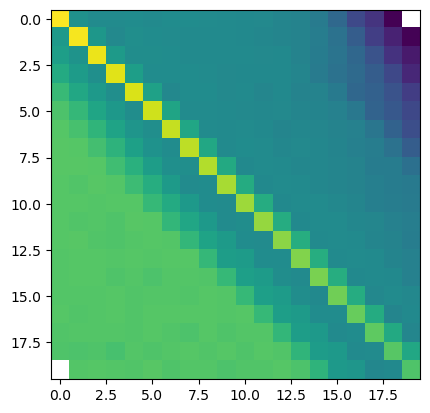

/var/folders/h3/s252cnjs1fg5q_2y8x3vh8mr0000gp/T/ipykernel_83807/2655252996.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(np.abs(rhoss)))


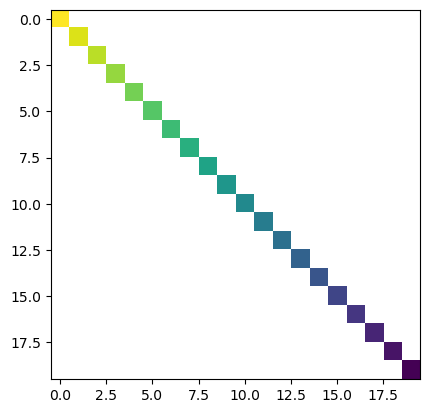

Error in numerics vs. analytics for rho_ss
4.3798335016052187e-14


In [36]:
#Calculate the steady state numerically
rhoss_num=get_steady_state(builder, model, 0.0)
print(np.trace(rhoss_num))
plt.imshow(np.log(np.abs(rhoss_num)))
plt.show()
M=expm(-beta*omega*(adag@a))
rhoss=M/np.trace(M)
plt.imshow(np.log(np.abs(rhoss)))
plt.show()
print("Error in numerics vs. analytics for rho_ss")
print(np.sum(np.abs(rhoss_num-rhoss)))